<a href="https://colab.research.google.com/github/parthmore30/speech-recognition./blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import librosa
import librosa.display

import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/dataset"


In [ ]:
import os

# List all files in the dataset folder
print("Files in dataset folder:")
print(os.listdir(dataset_path))


Files in dataset folder:
['YAF_fear', 'YAF_neutral', 'OAF_Sad', 'YAF_happy', 'YAF_sad', 'OAF_neutral', 'OAF_Pleasant_surprise', 'YAF_angry', 'YAF_pleasant_surprised', 'YAF_disgust', 'OAF_Fear', 'OAF_happy', 'OAF_disgust']


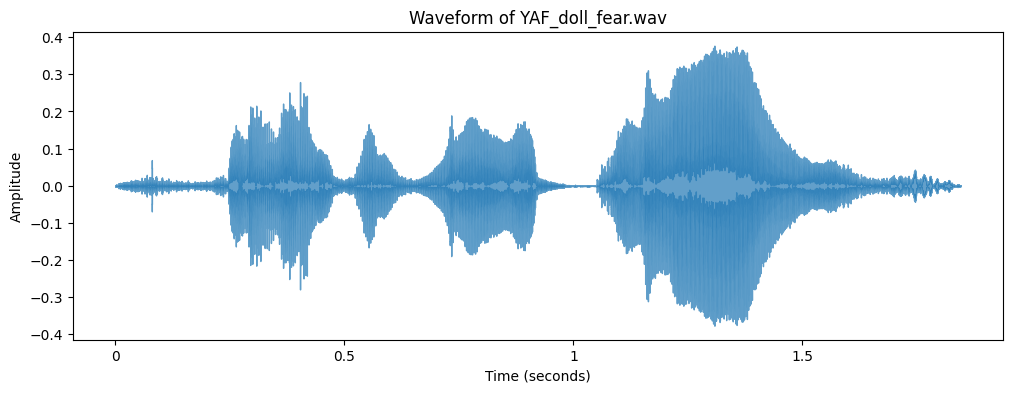

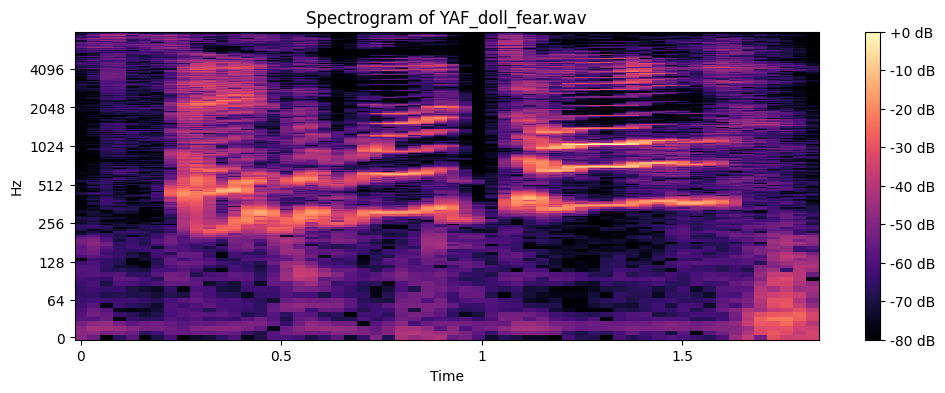

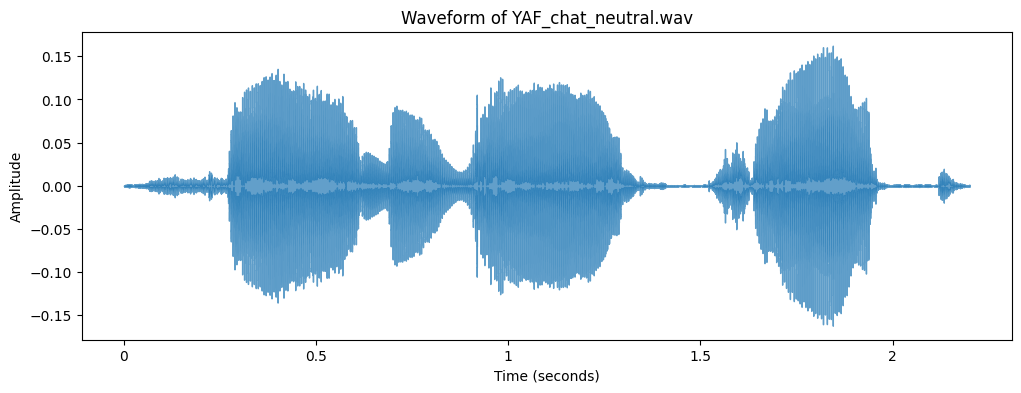

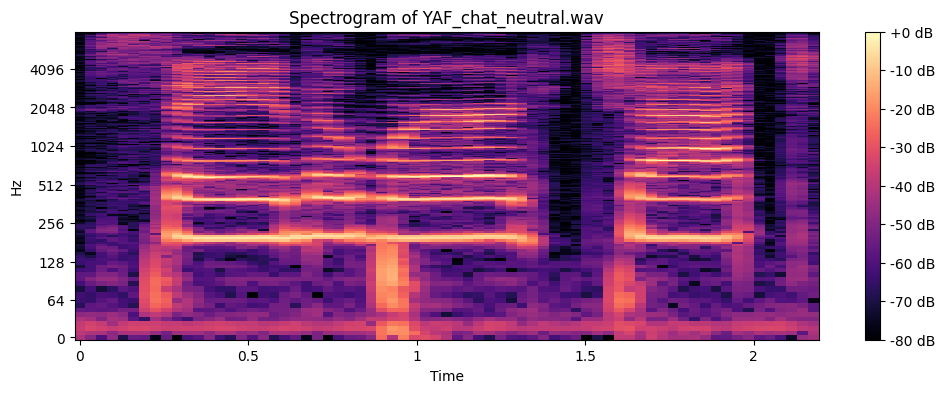

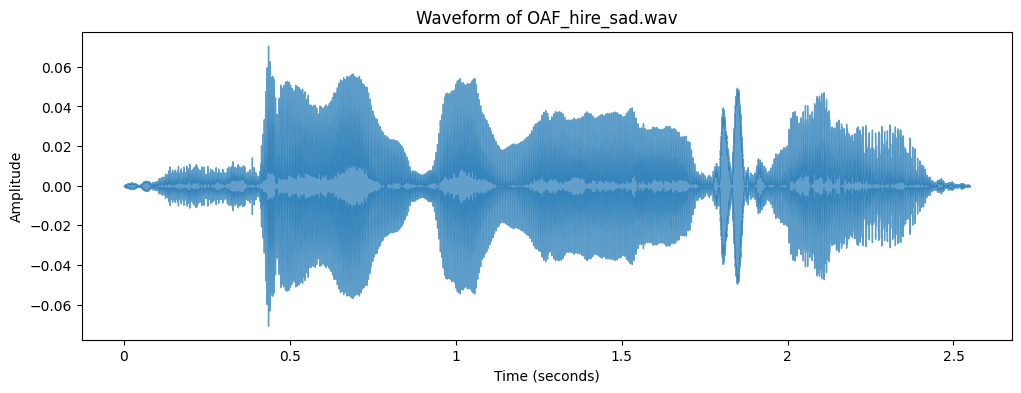

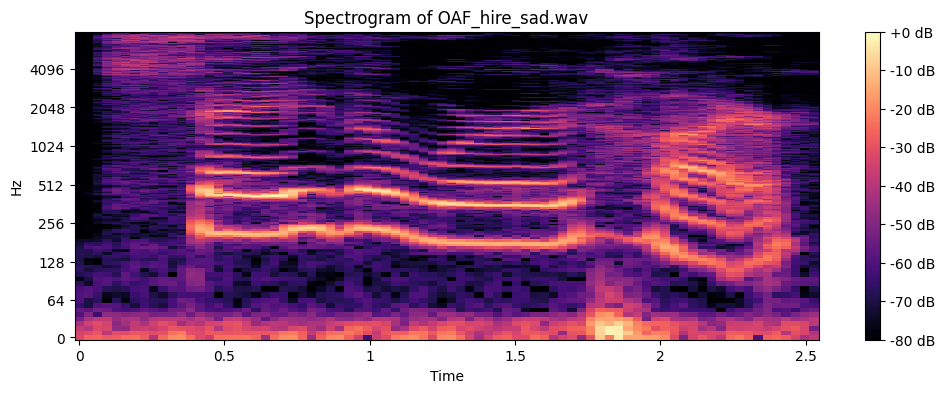

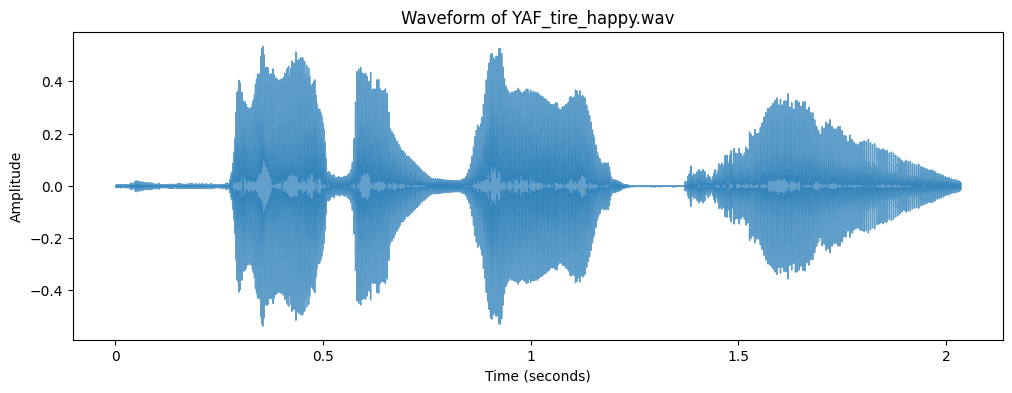

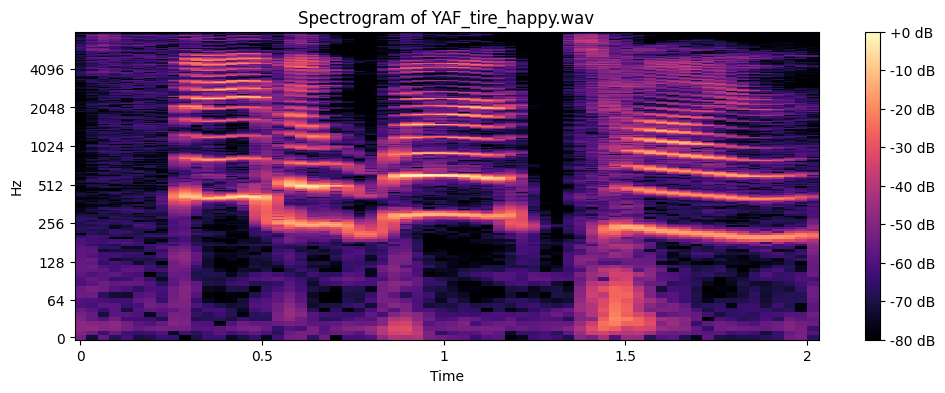

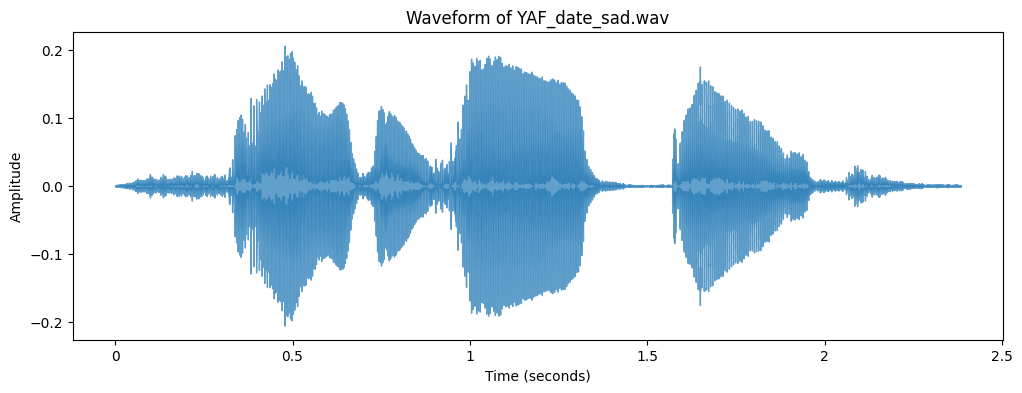

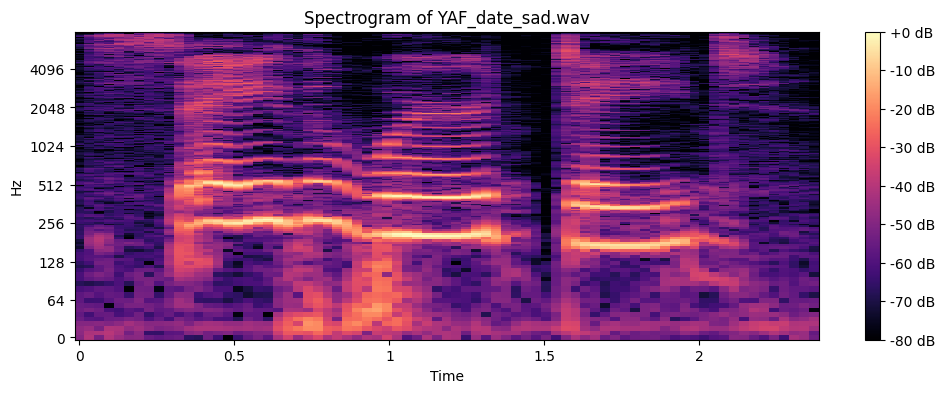

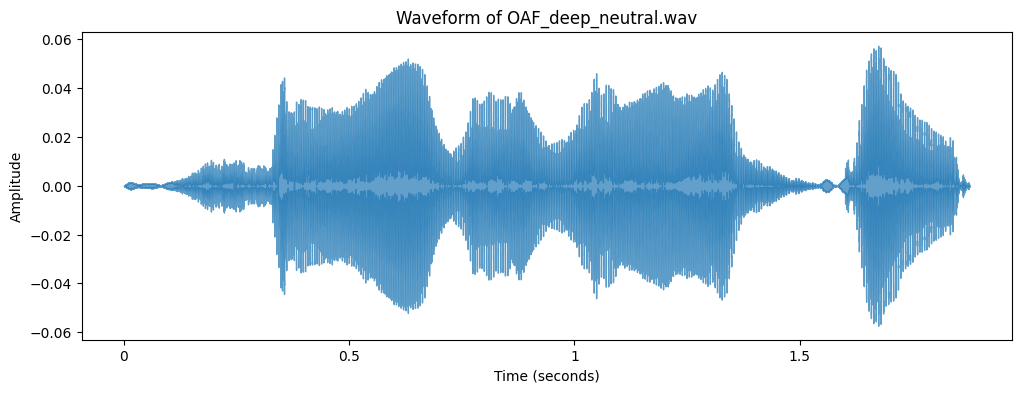

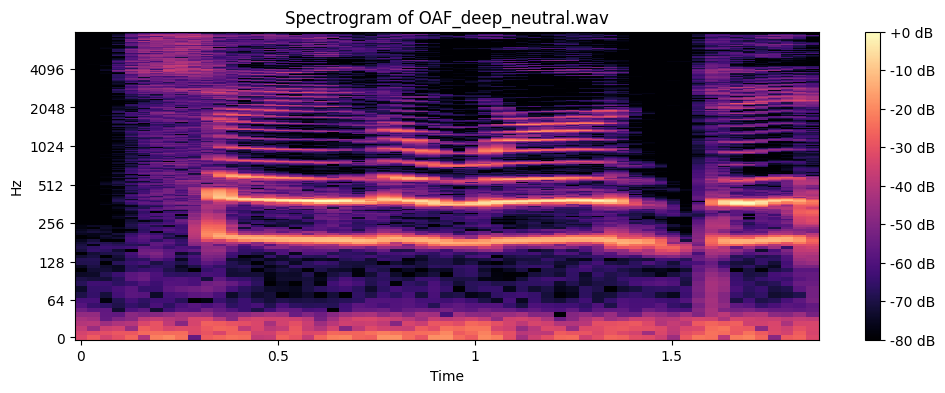

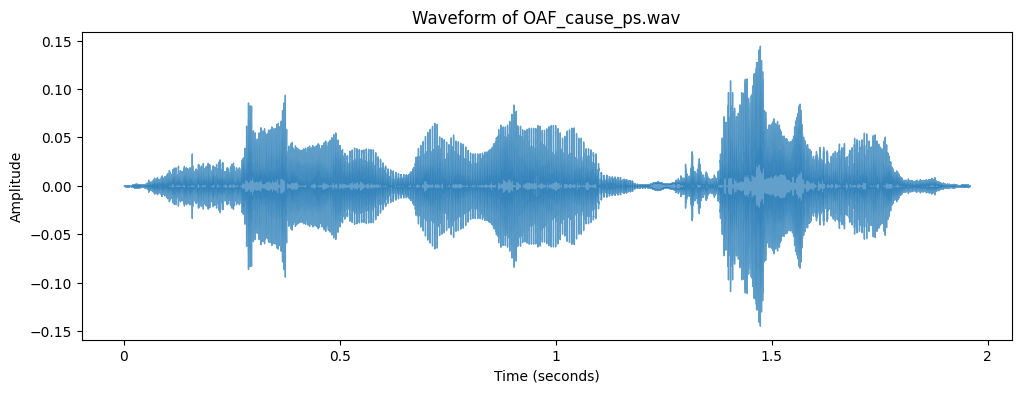

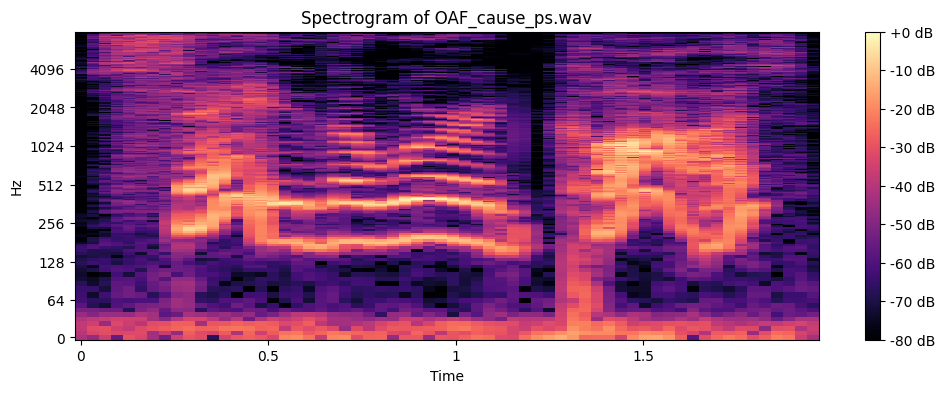

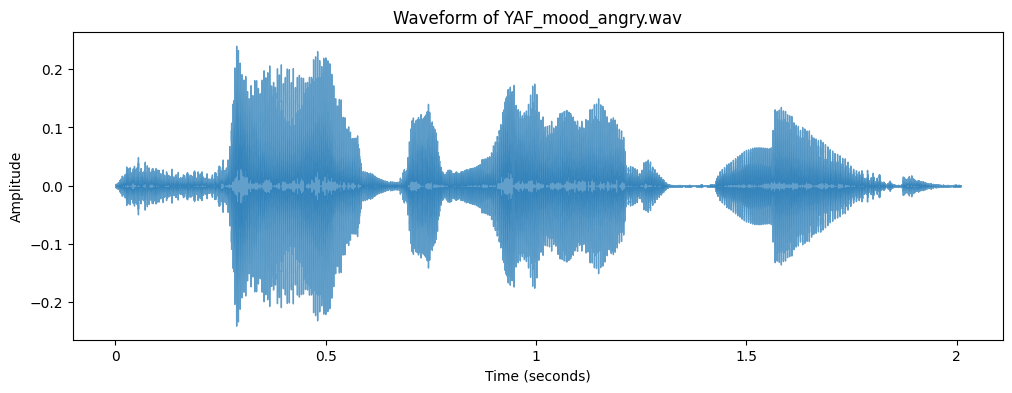

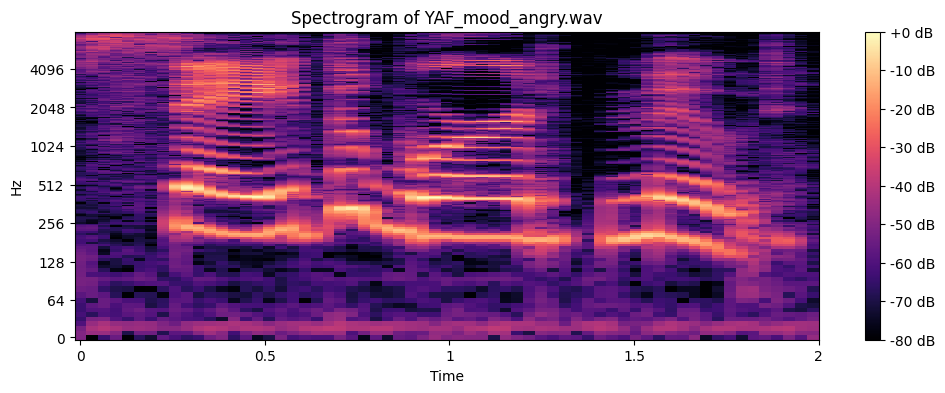

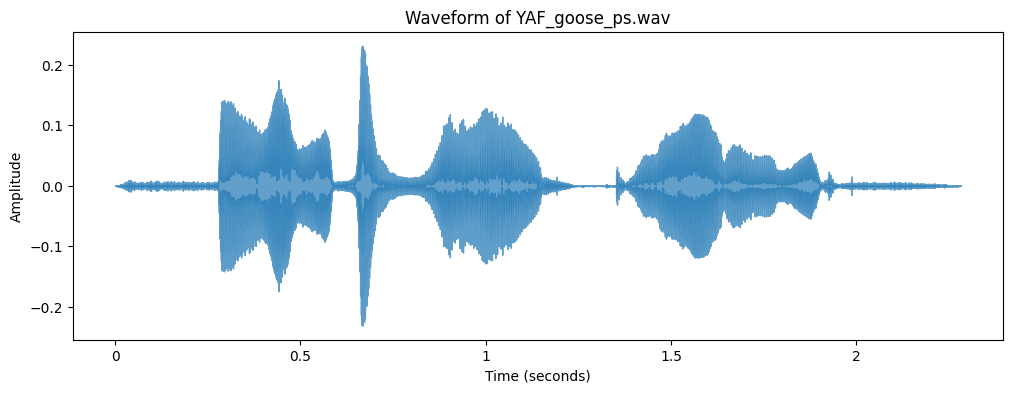

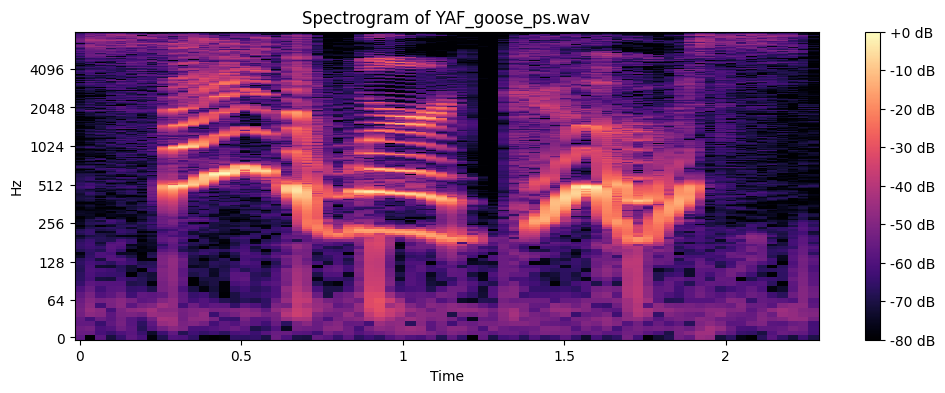

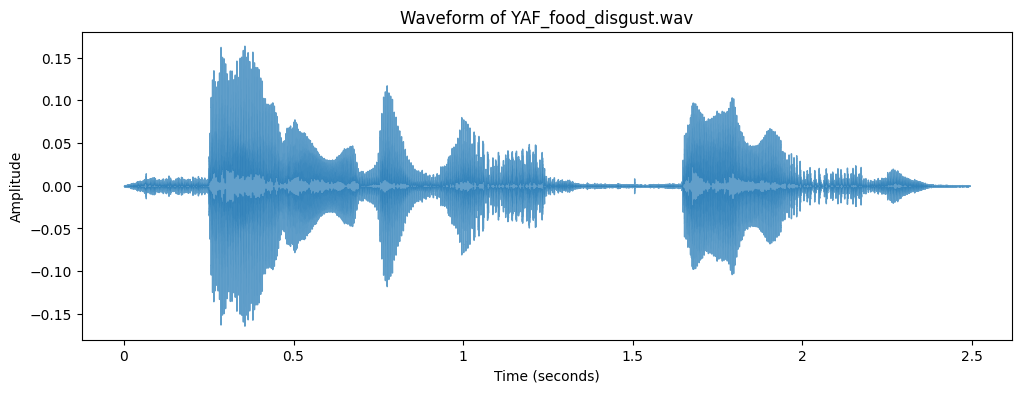

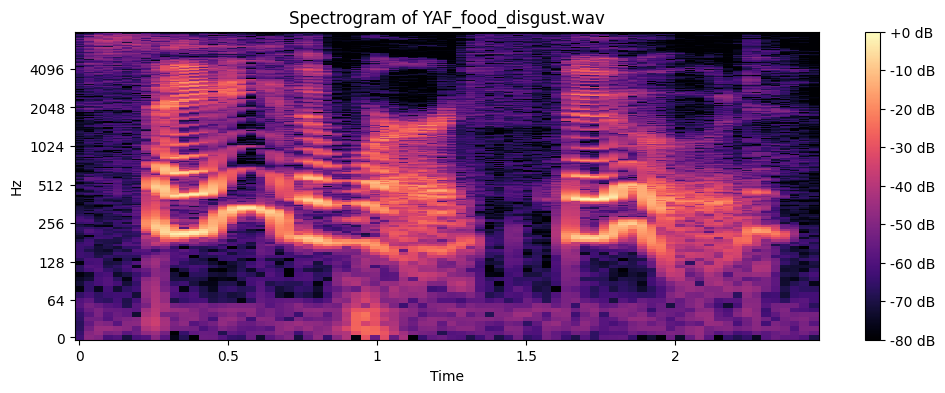

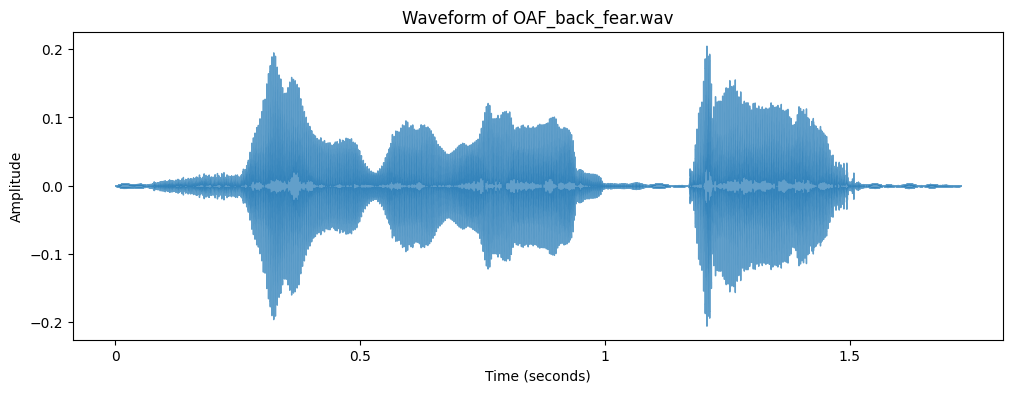

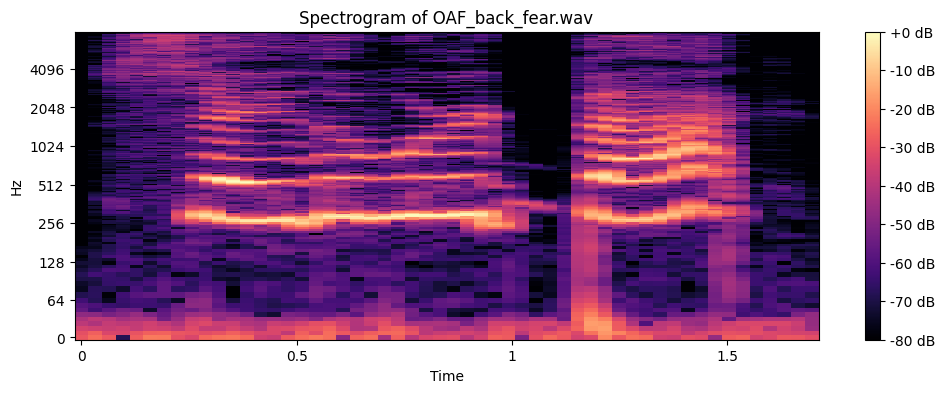

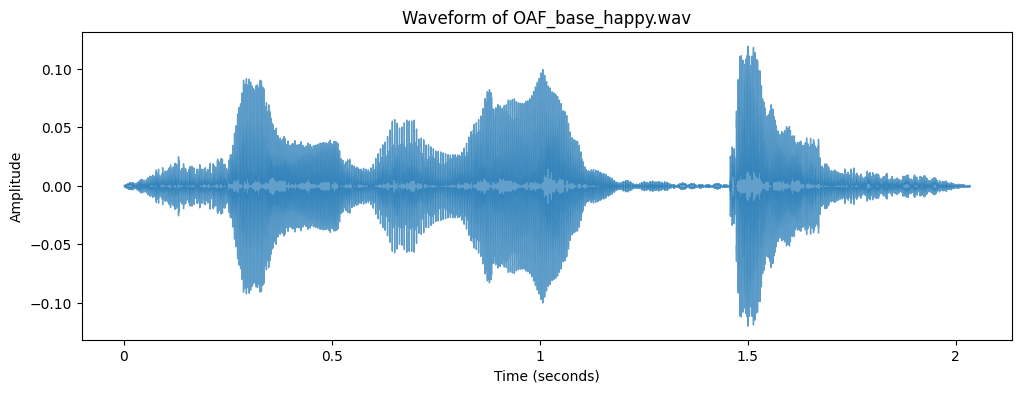

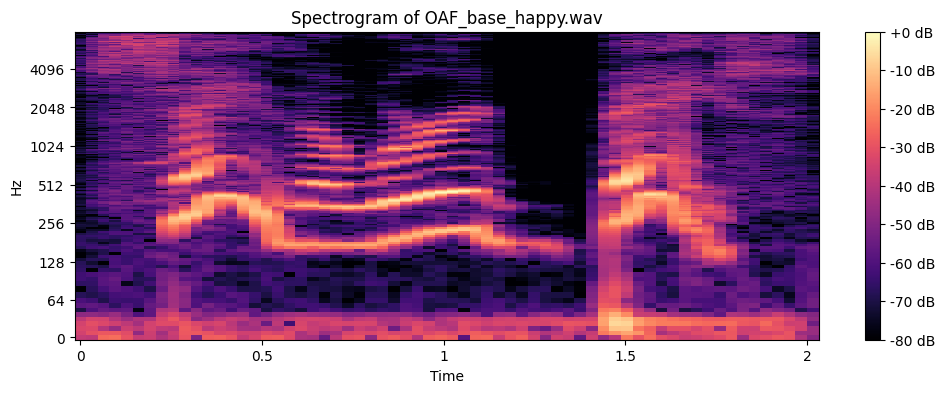

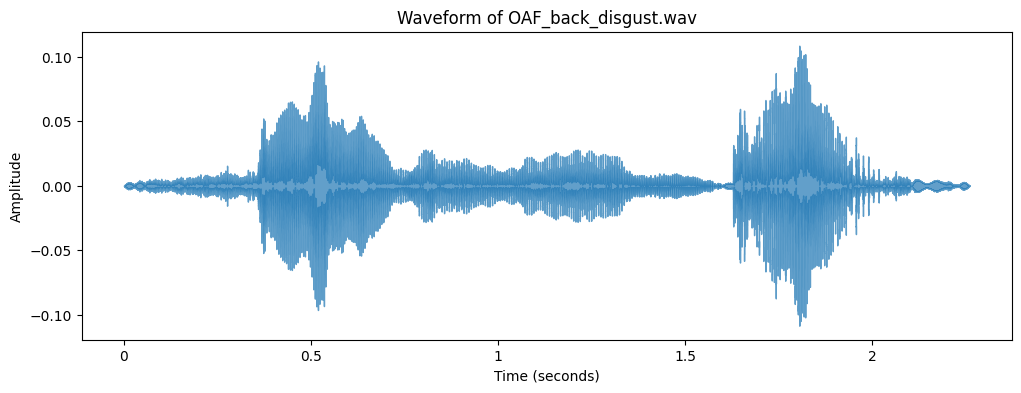

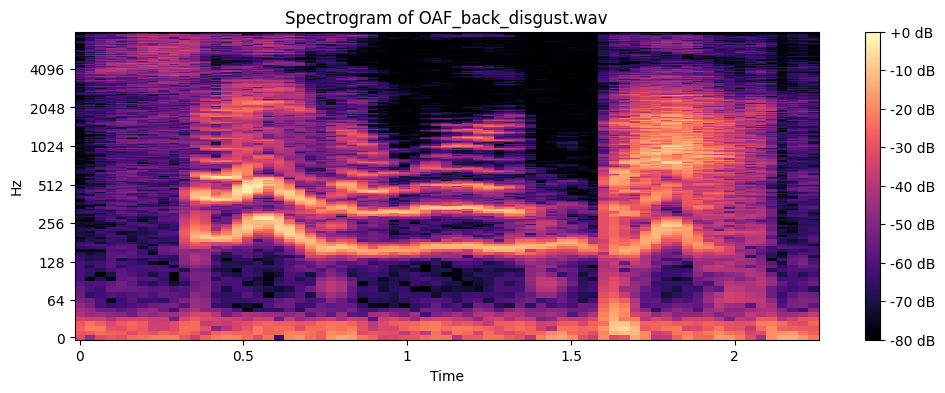

        Folder                  File       Pitch  Volume (RMS)      MFCC_1  \
0     YAF_fear     YAF_doll_fear.wav  200.654390      0.053605 -292.826202   
1  YAF_neutral  YAF_chat_neutral.wav  247.150704      0.024546 -383.892181   
2      OAF_Sad      OAF_hire_sad.wav  217.233276      0.013301 -477.861633   
3    YAF_happy    YAF_tire_happy.wav  218.787959      0.079534 -278.978699   
4      YAF_sad      YAF_date_sad.wav  212.193513      0.032483 -390.851105   

      MFCC_2     MFCC_3     MFCC_4     MFCC_5     MFCC_6     MFCC_7    MFCC_8  \
0  32.972328  -4.802316  -0.608011 -22.320032  14.093630 -15.051923 -6.894548   
1  40.427853  -2.040183  27.925411 -14.330029   5.502847 -15.698383 -1.243971   
2  86.537659  -0.489452   2.214680  16.245878  -2.319129 -25.921625 -9.544325   
3  26.764622 -17.020849  16.531502 -22.193359   3.481694 -22.827288  9.473911   
4  51.565525  33.962986  32.829712  -7.549335   6.594450 -15.591115  0.925311   

      MFCC_9    MFCC_10   MFCC_11   MFCC_12 

In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = "/content/drive/MyDrive/dataset"

# Function to extract audio features
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)

    # Pitch (Fundamental Frequency)
    pitch = librosa.yin(y, fmin=50, fmax=300)
    avg_pitch = np.mean(pitch)

    # Tone (MFCCs - Mel Frequency Cepstral Coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    avg_mfcc = np.mean(mfccs, axis=1)

    # Volume (RMS - Root Mean Square)
    rms = librosa.feature.rms(y=y)
    avg_rms = np.mean(rms)

    return y, sr, avg_pitch, avg_mfcc, avg_rms

# List to store extracted features
data = []

# Process one file from each folder
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):  # Ensure it's a directory
        files = [f for f in os.listdir(folder_path) if f.endswith('.wav') or f.endswith('.WAV')]

        if files:  # If the folder contains .wav files
            first_file = files[0]  # Select the first file
            file_path = os.path.join(folder_path, first_file)

            # Extract audio features
            y, sr, pitch, mfcc, rms = extract_features(file_path)

            # Plot the waveform
            plt.figure(figsize=(12, 4))
            librosa.display.waveshow(y, sr=sr, alpha=0.7)
            plt.title(f'Waveform of {first_file}')
            plt.xlabel('Time (seconds)')
            plt.ylabel('Amplitude')
            plt.show()

            # Plot the spectrogram
            plt.figure(figsize=(12, 4))
            D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
            librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f'Spectrogram of {first_file}')
            plt.show()

            # Append extracted features to the list
            data.append([folder, first_file, pitch, rms] + list(mfcc))

# Create a DataFrame
columns = ['Folder', 'File', 'Pitch', 'Volume (RMS)'] + [f'MFCC_{i+1}' for i in range(13)]
df = pd.DataFrame(data, columns=columns)

# Save the DataFrame to a CSV file
df.to_csv("audio_features.csv", index=False)

# Display the first few rows of the DataFrame
print(df.head())



In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import scipy.signal as signal
import soundfile as sf
import matplotlib.pyplot as plt

# Define dataset path
dataset_path = "/content/drive/MyDrive/dataset"
output_path = "/content/drive/MyDrive/filtered_dataset"  # Path to save cleaned audio files

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

# Function to apply noise filtering
def filter_noise(y, sr):
    # Step 1: Apply a bandpass filter (300Hz - 3400Hz)
    sos = signal.butter(4, [300, 3400], btype='bandpass', fs=sr, output='sos')
    y_filtered = signal.sosfilt(sos, y)

    # Step 2: Spectral noise reduction
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y_filtered)), ref=np.max)
    noise_threshold = np.percentile(D, 10)  # Adjust noise floor
    D_denoised = np.maximum(D - noise_threshold, 0)

    # Convert back to audio signal
    y_denoised = librosa.istft(librosa.db_to_amplitude(D_denoised))
    return y_denoised

# Iterate through all folders & files
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):  # Check if it's a folder
        output_folder = os.path.join(output_path, folder)
        os.makedirs(output_folder, exist_ok=True)  # Create output folder if not exists

        for file in os.listdir(folder_path):
            if file.endswith('.wav') or file.endswith('.WAV'):  # Check for audio files
                file_path = os.path.join(folder_path, file)

                # Load audio
                y, sr = librosa.load(file_path, sr=16000)

                # Apply noise filtering
                y_cleaned = filter_noise(y, sr)

                # Save the cleaned audio file
                output_file_path = os.path.join(output_folder, file)
                sf.write(output_file_path, y_cleaned, sr)

                print(f" Processed: {file}")

print("\n All audio files have been filtered and saved!")


 Processed: YAF_doll_fear.wav
 Processed: YAF_sure_fear.wav
 Processed: YAF_chair_fear.wav
 Processed: YAF_chalk_fear.wav
 Processed: YAF_dip_fear.wav
 Processed: YAF_late_fear.wav
 Processed: YAF_size_fear.wav
 Processed: YAF_which_fear.wav
 Processed: YAF_goal_fear.wav
 Processed: YAF_cab_fear.wav
 Processed: YAF_deep_fear.wav
 Processed: YAF_kite_fear.wav
 Processed: YAF_yearn_fear.wav
 Processed: YAF_learn_fear.wav
 Processed: YAF_jar_fear.wav
 Processed: YAF_have_fear.wav
 Processed: YAF_sheep_fear.wav
 Processed: YAF_base_fear.wav
 Processed: YAF_knock_fear.wav
 Processed: YAF_keg_fear.wav
 Processed: YAF_rush_fear.wav
 Processed: YAF_search_fear.wav
 Processed: YAF_hire_fear.wav
 Processed: YAF_dodge_fear.wav
 Processed: YAF_gin_fear.wav
 Processed: YAF_wash_fear.wav
 Processed: YAF_fit_fear.wav
 Processed: YAF_mess_fear.wav
 Processed: YAF_road_fear.wav
 Processed: YAF_take_fear.wav
 Processed: YAF_yes_fear.wav
 Processed: YAF_walk_fear.wav
 Processed: YAF_note_fear.wav
 Proces

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Path to cleaned audio
filtered_dataset_path = "/content/drive/MyDrive/filtered_dataset"

# Function to extract MFCCs
def extract_mfcc(file_path, max_pad_len=100):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    pad_width = max_pad_len - mfcc.shape[1]
    if pad_width > 0:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc.T  # Transpose for LSTM input

# Load dataset
data = []
labels = []
max_pad_len = 100  # Set padding length

for folder in os.listdir(filtered_dataset_path):
    folder_path = os.path.join(filtered_dataset_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                file_path = os.path.join(folder_path, file)
                mfcc = extract_mfcc(file_path, max_pad_len)
                data.append(mfcc)
                labels.append(folder)  # Assuming folder name is the label

# Convert to NumPy arrays
X = np.array(data)
y = np.array(labels)

# Encode labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_pad_len, dtype='float32', padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_pad_len, dtype='float32', padding='post', truncating='post')


In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()  # ✅ Define encoder
y_encoded = encoder.fit_transform(y)

# Get number of unique emotion classes
num_classes = len(encoder.classes_)  # ✅ Fix: Store number of classes

# Build LSTM model
model = Sequential([
    Masking(mask_value=0.0, input_shape=(max_pad_len, 13)),  # Ignore padded values
    LSTM(128, return_sequences=True, dropout=0.2),
    LSTM(128, return_sequences=False, dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # ✅ Use num_classes instead of encoder.classes_
])

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16)

# Save trained model
model.save("/content/drive/MyDrive/speech_lstm_model.h5")

print("\n✅ Model trained and saved successfully!")



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.1696 - loss: 2.4416 - val_accuracy: 0.5135 - val_loss: 1.5080
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.3297 - loss: 1.8607 - val_accuracy: 0.6423 - val_loss: 1.1230
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 42s 174ms/step - accuracy: 0.4580 - loss: 1.5805 - val_accuracy: 0.6673 - val_loss: 0.9379
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 24s 180ms/step - accuracy: 0.5350 - loss: 1.3334 - val_accuracy: 0.7327 - val_loss: 0.7959
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 39s 167ms/step - accuracy: 0.6040 - loss: 1.1273 - val_accuracy: 0.8000 - val_loss: 0.6094
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.6519 - loss: 0.9810 - val_accuracy: 0.8077 - val_loss: 0.5422
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 177ms/step - accuracy: 0.7210 - loss: 0.8305 - val_accuracy: 0.8558 - val_loss: 0.4402
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 176ms/step - accuracy: 0.7273 - loss: 0.8383 - val


✅ Model trained and saved successfully!


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the trained emotion detection model
model_path = "/content/drive/MyDrive/speech_lstm_model.h5"

if os.path.exists(model_path):
    model = load_model(model_path)
    print("✅ Emotion detection model loaded successfully!")
else:
    print("❌ Emotion detection model not found!")
    exit()

# Define dataset path (filtered audio files)
filtered_path = "/content/drive/MyDrive/filtered_dataset"

# Define emotion labels (Ensure this matches the training labels)
emotion_labels = ['Neutral', 'Happy', 'Sad', 'Angry']

# Function to extract MFCC features
def extract_mfcc(file_path, max_pad_len=100):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        if mfcc.shape[1] < max_pad_len:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_pad_len - mfcc.shape[1])), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc.T

    except Exception as e:
        print(f"❌ Error extracting MFCC from {file_path}: {e}")
        return None

# Store results
data = []

# Process only one file per folder
for folder in os.listdir(filtered_path):
    folder_path = os.path.join(filtered_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.wav') or file.endswith('.WAV'):
                file_path = os.path.join(folder_path, file)

                # Extract MFCC features for emotion detection
                mfcc_features = extract_mfcc(file_path)

                if mfcc_features is None:
                    continue

                mfcc_features = np.expand_dims(mfcc_features, axis=0)

                # Predict emotion using LSTM model
                predictions = model.predict(mfcc_features)
                emotion_index = np.argmax(predictions[0])

                # Ensure emotion_index is within valid range
                predicted_emotion = emotion_labels[emotion_index] if 0 <= emotion_index < len(emotion_labels) else max(zip(predictions[0], emotion_labels))[1]

                data.append([file, predicted_emotion])

                break  # Process only the first file in the folder

# Create DataFrame
df = pd.DataFrame(data, columns=["File Name", "Predicted Emotion"])

# Save results
output_path = "/content/drive/MyDrive/emotion_results.csv"
df.to_csv(output_path, index=False)

# Display first few results
print(df.head())

print(f"\n✅ Emotion detection completed! Results saved to {output_path}")



✅ Emotion detection model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
               File Name Predicted Emotion
0      YAF_sure_fear.wav           Neutral
1  YAF_mouse_neutral.wav             Happy
2      OAF_cause_sad.wav               Sad
3      YAF_lid_happy.wav           Neutral
4        YAF_beg_sad.wav               Sad

✅ Emotion detection completed! Results saved to /content/drive/MyDrive/emotion_results.csv
